# Marker Repo - annotation zebrahub using homology

This example shows the application of the homology functions of the Marker Repo by annotating and comparing already annotated data from Zebrahub with the transferred data from PanglaoDB.

## Loading packages

In [1]:
import markerrepo.marker_repo as mr
import markerrepo.wrappers as wrap
import markerrepo.annotation as annot
import scanpy as sc

%load_ext autoreload
%autoreload 2

## Settings

Specify path of the cloned repository and the h5ad file which is going to be annotated.

In [2]:
repo_path = "/mnt/workspace/mkessle/projects/annotate_by_marker_and_features"
h5ad_path = "/mnt/workspace/mkessle/master/refdata/zf_atlas_10dpf_v4_release.h5ad"

Load anndata

In [3]:
adata = sc.read_h5ad(h5ad_path)

Filter adata to keep clusters of 12 cell types only

In [4]:
wanted_cell_types = [
    'Muller cell',
    'amacrine cell',
    'central nervous system',
    'cartilage element',
    'liver',
    'kidney cell',
    'macrophage',
    'muscle',
    'neuronal stem cell',
    'intestine',
    'dermis',
    'vasculature'
]

adata_filtered = adata[adata.obs['zebrafish_anatomy_ontology_class'].isin(wanted_cell_types)]

List all possible settings.

In [5]:
annot.list_possible_settings(repo_path, adata_filtered)

Possible Settings:
----------------------------------------
1. Possible Organisms or Taxon IDs:
  - human 9606
  - mouse 10090
  - zebrafish 7955
  - rat 10114
  - pig 9823
  - medaka 8090
  - chicken 9031
  - drosophila 7215
  - yeast 4932

2. Available Columns in adata.obs:
  - n_genes
  - n_counts
  - fish
  - timepoint_cluster
  - n_genes_by_counts
  - total_counts
  - total_counts_mt
  - pct_counts_mt
  - total_counts_nc
  - pct_counts_nc
  - zebrafish_anatomy_ontology_class
  - zebrafish_anatomy_ontology_id
  - developmental_stage
  - timepoint

3. Available Columns in adata.var:
  - gene_ids
  - feature_types
  - genome
  - mt
  - nc
  - n_cells_by_counts
  - mean_counts
  - pct_dropout_by_counts
  - total_counts
  - n_cells

4. Available Columns to Search in Marker Repository:
  - List name
  - Marker type
  - Organism name
  - Taxonomy ID
  - Submitter name
  - List type
  - Source
  - tags_transferred
  - Tissue
  - Date
  - Email
  - Marker
  - Info
-------------------------

In [6]:
# taxonomy ID or organism name e.g. "human" or 9606
organism = "zebrafish" 
# the column of the .obs table where the ranked genes groups are stored e.g. "rank_genes_groups"
# if no ranking has been performed yet, enter None
rank_genes_column = None
# the column of the .var table where the gene symbols or ensembl IDs or stored
# enter None if the index column of the .var table are already gene symbols or ensembl IDs 
# which you want to use for your annotation
genes_column = None
# the .obs table column of the clustering you want to annotate e.g. "leiden" or "louvain"
column = "zebrafish_anatomy_ontology_class"
# specify wether your index of the .var tables are ensembl IDs (True) or gene symbols (False)
ensembl = False
# specify the marker lists selection you want to use for the annotation
# the column to search in, None to search all columns, e.g. "source", "Organism name", etc.
col_to_search = "Source"
# search terms: "-" exclude keyword, "+" must contain keyword
# separate keywords with  "," e.g. ["+panglao.se", "+mouse"]
search_terms = ["panglao.se"]

Validate input and load anndata object

In [7]:
annot.validate_settings(repo_path, adata_filtered, organism, rank_genes_column, genes_column, column, ensembl, col_to_search, search_terms)

Initiating whitelist fetching...
Directory /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/metadata_whitelists already exists.
Updating the existing repository...
Repository updated.
Whitelist fetching process completed.

All settings are valid.
Summary of settings:
----------------------------------------
  Repo path: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features
  Organism: zebrafish
  Rank genes column: None
  Genes column: None
  Clustering column: zebrafish_anatomy_ontology_class
  Ensembl IDs: False
  Column to search: Source
  Search terms: ['panglao.se']
----------------------------------------


True

## Prepare annotation

### Ranking

Rank genes, if not already done.

In [8]:
if not rank_genes_column:
    rank_genes_column = f'rank_genes_groups_{column}'
    print(f'Ranking genes groups for clusters using obs column {column}')
    sc.tl.rank_genes_groups(adata_filtered, groupby=f'{column}', use_raw=False, key_added=rank_genes_column)

Ranking genes groups for clusters using obs column zebrafish_anatomy_ontology_class


/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:580: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


         Falling back to preprocessing with `sc.pp.pca` and default params.


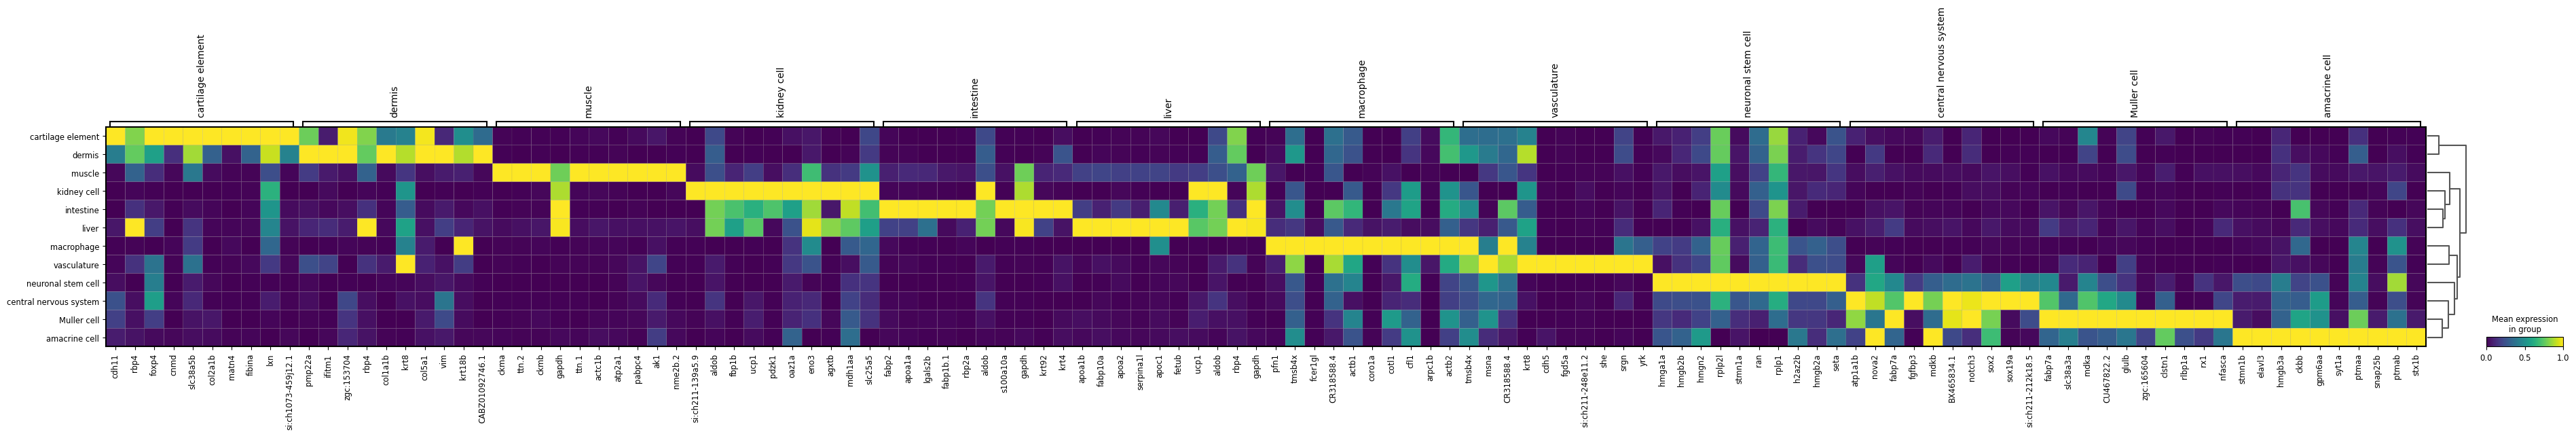

In [9]:
sc.pl.rank_genes_groups_matrixplot(adata_filtered, standard_scale='var', n_genes=10, key=rank_genes_column, show=True)

## Create suitable marker list(s)

The paths of the marker lists will be stored in the <b>marker_lists</b> variable. They will work as input for the actual cell type annotation of the next cell. If the index of adata.var contains ensembl IDs, set <b>ensembl=True</b>, otherwise gene symbols are used.

Add transferred marker lists using the whole PanglaoDB as source.

Trying to create marker lists via homology...
Loading genes of zebrafish...
Done!


The following source organisms can be used in both approaches: mouse 10090, human 9606.

Starting HomoloGene approach...
Loading genes of mouse...
Done!


DataFrame of the markers of the source organism (mouse) to be transferred to the target organism (zebrafish):


,Marker,Info
0,CGA ENSMUSG00000028298,Erythroblasts
1,TFRC ENSMUSG00000022797,Erythroblasts
2,CDH1 ENSMUSG00000000303,Erythroblasts
3,WRN ENSMUSG00000031583,Erythroblasts
4,CD44 ENSMUSG00000005087,Erythroblasts
...,...,...
8079,SLC14A1 ENSMUSG00000059336,Urothelial cells
8080,UPK3A ENSMUSG00000022435,Urothelial cells
8081,UPK1A ENSMUSG00000006313,Urothelial cells
8082,UPK2 ENSMUSG00000041523,Urothelial cells


Filter source DataFrame by the number of target genes per source gene: remove all source genes that lead to more than 1 target genes.

The Marker Transfer Rate is 79.21%, indicating the percentage of successfully transferred markers from the source to the target organism.

General information:
Percentage of genes that can potentially be transferred from the source organism: 25.35%
If all genes from the source organism were transferred, they would cover 32.30% of all genes of the target organism.

Count of target genes per source gene:


,Source Gene,Count target genes
185,AA987161,655
12048,ZFP738 ENSMUSG00000048280,655
179,A530054K11RIK,655
7526,PCDHB3 ENSMUSG00000045498,63
7301,OLFR935 ENSMUSG00000059595,25
...,...,...
4325,GMIP ENSMUSG00000036246,1
4326,GMNC ENSMUSG00000068428,1
4327,GMNN ENSMUSG00000006715,1
4328,GMPPA ENSMUSG00000033021,1


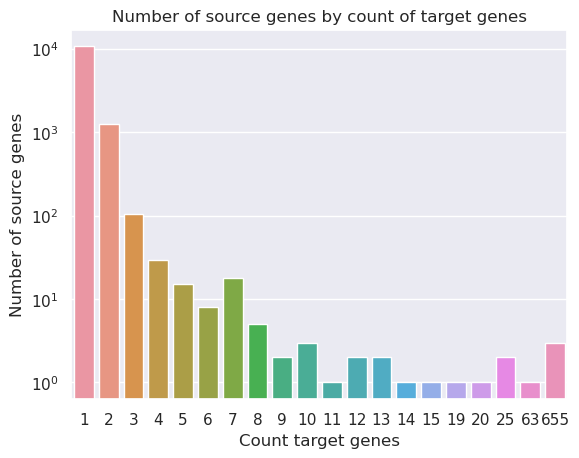

Filtered source DataFrame with target_counts <= 1:


,Marker,Info
0,CGA ENSMUSG00000028298,Erythroblasts
1,CGA ENSMUSG00000028298,Interneurons
2,WRN ENSMUSG00000031583,Erythroblasts
3,WRN ENSMUSG00000031583,Basophils
4,BCL11A ENSMUSG00000000861,Erythroblasts
...,...,...
4136,MYLK4 ENSMUSG00000044951,Smooth muscle cells
4137,KIF1C ENSMUSG00000020821,Smooth muscle cells
4138,SH3BGR ENSMUSG00000040666,Smooth muscle cells
4139,UMODL1 ENSMUSG00000054134,Urothelial cells


Filtered: 3943 source genes, 48.78%

Create DataFrame containing the transferred genes based on the filter criteria.

The Marker Transfer Rate is 99.90%, indicating the percentage of successfully transferred markers from the source to the target organism.

Transferred markers:


,Marker,Info
0,CGA ENSDARG00000103345,Erythroblasts
1,CGA ENSDARG00000103345,Interneurons
2,WRN ENSDARG00000098211,Erythroblasts
3,WRN ENSDARG00000098211,Basophils
4,BCL11AA ENSDARG00000061352,Erythroblasts
...,...,...
4136,LOC566845,Smooth muscle cells
4137,KIF1C ENSDARG00000098655,Smooth muscle cells
4138,SH3BGR ENSDARG00000021633,Smooth muscle cells
4139,UMODL1 ENSDARG00000068923,Urothelial cells


Weighted transferred markers:


,Marker,Info,Score
2068,COL14A1A ENSDARG00000005762,Fibroblasts,0.0
2607,RIMBP2 ENSDARG00000104101,Enteroendocrine cells,0.0
2612,CPE ENSDARG00000055874,Enteroendocrine cells,0.0
2613,MC4R ENSDARG00000015515,Enteroendocrine cells,0.0
2618,SULT1ST6 ENSDARG00000006811,Foveolar cells,0.0
...,...,...,...
919,ISL1 ENSDARG00000004023,Pancreatic progenitor cells,1.0
920,ISL1 ENSDARG00000004023,Satellite cells,1.0
908,ISL1 ENSDARG00000004023,Interneurons,1.0
915,ISL1 ENSDARG00000004023,Cardiac stem and precursor cells,1.0


Folder /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/examples/transferred_markers created.
Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/examples/transferred_markers/mouse_zebrafish_HomoloGene_annotation
Loading genes of human...
Done!


DataFrame of the markers of the source organism (human) to be transferred to the target organism (zebrafish):


,Marker,Info
0,CGA ENSG00000135346,Erythroblasts
1,TFRC ENSG00000072274,Erythroblasts
2,CDH1 ENSG00000039068,Erythroblasts
3,WRN ENSG00000165392,Erythroblasts
4,CD44 ENSG00000026508,Erythroblasts
...,...,...
8045,SLC14A1 ENSG00000141469,Urothelial cells
8046,UPK3A ENSG00000100373,Urothelial cells
8047,UPK1A ENSG00000105668,Urothelial cells
8048,UPK2 ENSG00000110375,Urothelial cells


Filter source DataFrame by the number of target genes per source gene: remove all source genes that lead to more than 1 target genes.

The Marker Transfer Rate is 79.43%, indicating the percentage of successfully transferred markers from the source to the target organism.

General information:
Percentage of genes that can potentially be transferred from the source organism: 23.07%
If all genes from the source organism were transferred, they would cover 31.58% of all genes of the target organism.

Count of target genes per source gene:


,Source Gene,Count target genes
12026,ZNF729 ENSG00000196350,655
7444,PCDHB3 ENSG00000113205,63
7442,PCDHA8 ENSG00000204962,40
4651,HIST2H2BE,31
7237,OR8G5 ENSG00000255298,25
...,...,...
4293,GPR142 ENSG00000257008,1
4294,GPR143 ENSG00000101850,1
4295,GPR144,1
4296,GPR146 ENSG00000164849,1


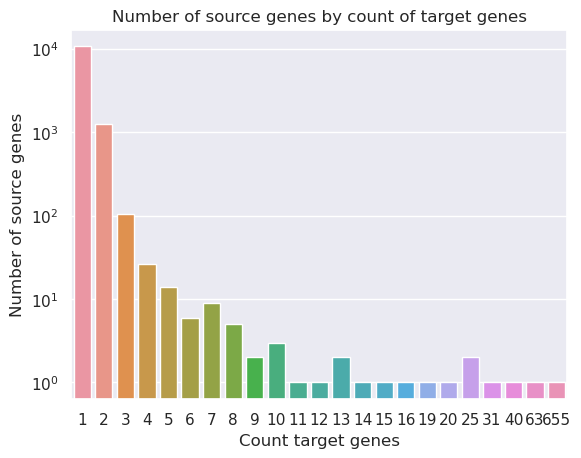

Filtered source DataFrame with target_counts <= 1:


,Marker,Info
0,CGA ENSG00000135346,Erythroblasts
1,CGA ENSG00000135346,Interneurons
2,WRN ENSG00000165392,Erythroblasts
3,WRN ENSG00000165392,Basophils
4,BCL11A ENSG00000119866,Erythroblasts
...,...,...
4116,SEC24D ENSG00000150961,Smooth muscle cells
4117,MYLK4 ENSG00000145949,Smooth muscle cells
4118,KIF1C ENSG00000129250,Smooth muscle cells
4119,UMODL1 ENSG00000177398,Urothelial cells


Filtered: 3929 source genes, 48.81%

Create DataFrame containing the transferred genes based on the filter criteria.

The Marker Transfer Rate is 100.00%, indicating the percentage of successfully transferred markers from the source to the target organism.

Transferred markers:


,Marker,Info
0,CGA ENSDARG00000103345,Erythroblasts
1,CGA ENSDARG00000103345,Interneurons
2,WRN ENSDARG00000098211,Erythroblasts
3,WRN ENSDARG00000098211,Basophils
4,BCL11AA ENSDARG00000061352,Erythroblasts
...,...,...
4116,SEC24D ENSDARG00000045946,Smooth muscle cells
4117,LOC566845,Smooth muscle cells
4118,KIF1C ENSDARG00000098655,Smooth muscle cells
4119,UMODL1 ENSDARG00000068923,Urothelial cells


Weighted transferred markers:


,Marker,Info,Score
4120,UPK1A ENSDARG00000021866,Urothelial cells,0.0
2964,CCNB1 ENSDARG00000051923,Gamma delta T cells,0.0
1185,TBXAS1 ENSDARG00000002249,Microglia,0.0
2965,CPM ENSDARG00000011769,Macrophages,0.0
2971,RBPJB ENSDARG00000052091,Macrophages,0.0
...,...,...,...
904,ISL1 ENSDARG00000004023,Neuroblasts,1.0
903,ISL1 ENSDARG00000004023,Motor neurons,1.0
902,ISL1 ENSDARG00000004023,Interneurons,1.0
907,ISL1 ENSDARG00000004023,Photoreceptor cells,1.0


Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/examples/transferred_markers/human_zebrafish_HomoloGene_annotation

Starting BioMart approach...

Specify BioMart target organism selection:
Selection: drerio


Specify BioMart source organism selection:
Default organism: mmusculus
Loading genes of mouse...
Done!

Fetch necessary data from BioMart...

DataFrame of the markers of the source organism (mouse) to be transferred to the target organism (zebrafish):


,Marker,Info
0,CGA ENSMUSG00000028298,Erythroblasts
1,TFRC ENSMUSG00000022797,Erythroblasts
2,CDH1 ENSMUSG00000000303,Erythroblasts
3,WRN ENSMUSG00000031583,Erythroblasts
4,CD44 ENSMUSG00000005087,Erythroblasts
...,...,...
8079,SLC14A1 ENSMUSG00000059336,Urothelial cells
8080,UPK3A ENSMUSG00000022435,Urothelial cells
8081,UPK1A ENSMUSG00000006313,Urothelial cells
8082,UPK2 ENSMUSG00000041523,Urothelial cells


Filter source DataFrame by the number of target genes per source gene: remove all source genes that lead to more than 1 target genes.

The Marker Transfer Rate is 127.68%, indicating the percentage of successfully transferred markers from the source to the target organism.

General information:
Percentage of genes that can potentially be transferred from the source organism: 41.89%
If all genes from the source organism were transferred, they would cover 71.67% of all genes of the target organism.

Count of target genes per source gene:


,Source Gene,Count target genes
3227,TRAC ENSMUSG00000076928,37
1700,CD22 ENSMUSG00000030577,35
3226,TRDV1 ENSMUSG00000076864,32
3139,HTRA2 ENSMUSG00000068329,25
999,MS4A7 ENSMUSG00000024672,24
...,...,...
1329,SNX16 ENSMUSG00000027534,1
1330,NFATC2 ENSMUSG00000027544,1
1331,SALL4 ENSMUSG00000027547,1
1335,COL9A3 ENSMUSG00000027570,1


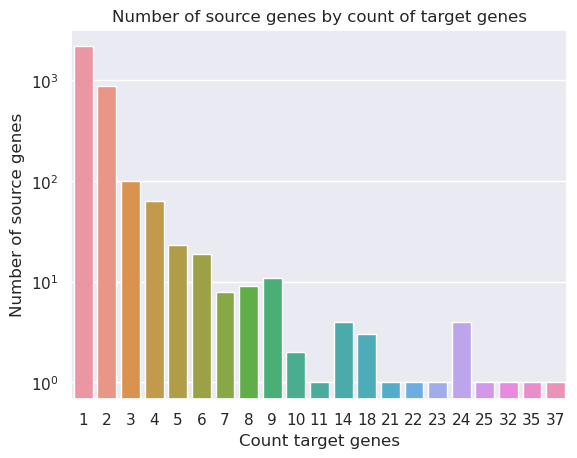

Filtered source DataFrame with target_counts <= 1:


,Marker,Info
0,CDH1 ENSMUSG00000000303,Erythroblasts
1,CDH1 ENSMUSG00000000303,Satellite glial cells
2,CDH1 ENSMUSG00000000303,Epiblast cells
3,CDH1 ENSMUSG00000000303,Epithelial cells
4,CDH1 ENSMUSG00000000303,Mesothelial cells
...,...,...
3735,SH3BGR ENSMUSG00000040666,Smooth muscle cells
3736,UMODL1 ENSMUSG00000054134,Urothelial cells
3737,SLC14A1 ENSMUSG00000059336,Urothelial cells
3738,UPK1A ENSMUSG00000006313,Urothelial cells


Filtered: 4344 source genes, 53.74%

Create DataFrame containing the transferred genes based on the filter criteria.

The Marker Transfer Rate is 100.00%, indicating the percentage of successfully transferred markers from the source to the target organism.

Transferred markers:


,Marker,Info
0,CDH2 ENSDARG00000018693,Hematopoietic stem cells
1,HGD ENSDARG00000058005,Proximal tubule cells
2,DSC2L ENSDARG00000039677,Keratinocytes
5,SI:CH73-74H11.1 ENSDARG00000062750,Trichocytes
6,LMNB1 ENSDARG00000044299,Erythroblasts
...,...,...
3735,EHF ENSDARG00000052115,Delta cells
3736,EHF ENSDARG00000052115,Langerhans cells
3737,SPRED1 ENSDARG00000041449,Mast cells
3738,LRRC57 ENSDARG00000043938,Germ cells


Weighted transferred markers:


,Marker,Info,Score
0,CDH2 ENSDARG00000018693,Hematopoietic stem cells,0.0
1868,SLC7A7 ENSDARG00000055226,Macrophages,0.0
1865,RAB30 ENSDARG00000037884,Dendritic cells,0.0
3738,LRRC57 ENSDARG00000043938,Germ cells,0.0
1861,CADPS2 ENSDARG00000013312,Dopaminergic neurons,0.0
...,...,...,...
163,SI:DKEY-30C15.12 ENSDARG00000058546,Airway epithelial cells,1.0
164,SI:DKEY-30C15.12 ENSDARG00000058546,Luminal epithelial cells,1.0
166,SI:DKEY-30C15.12 ENSDARG00000058546,Satellite cells,1.0
158,SI:DKEY-30C15.12 ENSDARG00000058546,Plasmacytoid dendritic cells,1.0


Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/examples/transferred_markers/mouse_zebrafish_BioMart_annotation

Specify BioMart source organism selection:
Selection: hsapiens

Loading genes of human...
Done!

Fetch necessary data from BioMart...

DataFrame of the markers of the source organism (human) to be transferred to the target organism (zebrafish):


,Marker,Info
0,CGA ENSG00000135346,Erythroblasts
1,TFRC ENSG00000072274,Erythroblasts
2,CDH1 ENSG00000039068,Erythroblasts
3,WRN ENSG00000165392,Erythroblasts
4,CD44 ENSG00000026508,Erythroblasts
...,...,...
8045,SLC14A1 ENSG00000141469,Urothelial cells
8046,UPK3A ENSG00000100373,Urothelial cells
8047,UPK1A ENSG00000105668,Urothelial cells
8048,UPK2 ENSG00000110375,Urothelial cells


Filter source DataFrame by the number of target genes per source gene: remove all source genes that lead to more than 1 target genes.

The Marker Transfer Rate is 130.17%, indicating the percentage of successfully transferred markers from the source to the target organism.

General information:
Percentage of genes that can potentially be transferred from the source organism: 35.96%
If all genes from the source organism were transferred, they would cover 67.35% of all genes of the target organism.

Count of target genes per source gene:


,Source Gene,Count target genes
76,CD22 ENSG00000012124,35
922,HTRA2 ENSG00000115317,25
770,MS4A6A ENSG00000110077,24
2379,MS4A7 ENSG00000166927,24
2380,MS4A5 ENSG00000166930,24
...,...,...
1309,MNX1 ENSG00000130675,1
1310,GATA5 ENSG00000130700,1
1311,LAMA5 ENSG00000130702,1
1312,ASS1 ENSG00000130707,1


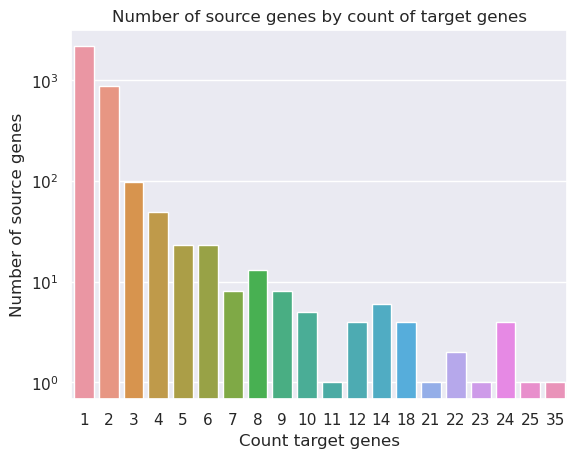

Filtered source DataFrame with target_counts <= 1:


,Marker,Info
0,CDH1 ENSG00000039068,Erythroblasts
1,CDH1 ENSG00000039068,Satellite glial cells
2,CDH1 ENSG00000039068,Epiblast cells
3,CDH1 ENSG00000039068,Epithelial cells
4,CDH1 ENSG00000039068,Mesothelial cells
...,...,...
3709,SH3BGR ENSG00000185437,Smooth muscle cells
3710,UMODL1 ENSG00000177398,Urothelial cells
3711,SLC14A1 ENSG00000141469,Urothelial cells
3712,UPK1A ENSG00000105668,Urothelial cells


Filtered: 4336 source genes, 53.86%

Create DataFrame containing the transferred genes based on the filter criteria.

The Marker Transfer Rate is 100.00%, indicating the percentage of successfully transferred markers from the source to the target organism.

Transferred markers:


,Marker,Info
0,CRYL1 ENSDARG00000003675,Proximal tubule cells
1,CLDN17 ENSDARG00000099950,Distal tubule cells
2,CLDN17 ENSDARG00000099950,Loop of Henle cells
3,CBY1 ENSDARG00000077409,Germ cells
4,POU4F1 ENSDARG00000005559,Retinal ganglion cells
...,...,...
3709,RYR2B ENSDARG00000003706,Neurons
3710,RYR2B ENSDARG00000003706,Cardiomyocytes
3711,CSF3R ENSDARG00000045959,Microglia
3712,CSF3R ENSDARG00000045959,Monocytes


Weighted transferred markers:


,Marker,Info,Score
0,CRYL1 ENSDARG00000003675,Proximal tubule cells,0.0
2506,TMEM53 ENSDARG00000038789,Germ cells,0.0
1078,KLHL2 ENSDARG00000061786,Oligodendrocytes,0.0
2510,NOX5 ENSDARG00000079773,Platelets,0.0
2514,KCNQ3 ENSDARG00000060085,Pyramidal cells,0.0
...,...,...,...
1971,SI:DKEY-30C15.12 ENSDARG00000058546,Luminal epithelial cells,1.0
1972,SI:DKEY-30C15.12 ENSDARG00000058546,Mammary epithelial cells,1.0
1973,SI:DKEY-30C15.12 ENSDARG00000058546,Satellite cells,1.0
1966,SI:DKEY-30C15.12 ENSDARG00000058546,Hepatoblasts,1.0


Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/examples/transferred_markers/human_zebrafish_BioMart_annotation

Finished!


In [10]:
organism = mr.update_organism(organism, repo_path)
marker_lists = wrap.create_marker_lists(organism, repo_path=repo_path, 
                                        style="score", file_name="zebrahub_transferred", ensembl=ensembl,
                                        col_to_search=col_to_search, search_terms=search_terms, force_homology=True)

Add non-transferred marker lists from mouse and human

In [11]:
col_to_search = "Source"
search_terms = ["panglao.se"]

marker_list_mouse = wrap.create_marker_lists("mouse", repo_path=repo_path, 
                                        style="score", file_name="zebrahub_no_homology_mouse", ensembl=ensembl,
                                        col_to_search=col_to_search, search_terms=search_terms, force_homology=False)
marker_list_human = wrap.create_marker_lists("human", repo_path=repo_path, 
                                        style="score", file_name="zebrahub_no_homology_human", ensembl=ensembl,
                                        col_to_search=col_to_search, search_terms=search_terms, force_homology=False)

marker_lists.extend([lst[0] for lst in [marker_list_mouse, marker_list_human] if lst])

Found 30 marker lists for the given organism mouse.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Tissue,Date,Email,Marker,Info
ID,,,,,,,,,,,,,
168874554335914,Panglao_mouse_zygote,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,zygote,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[PML, ENSMUSG00000036986, NANOG, ENSMUSG000000...",[Embryonic stem cells]
168874554346271,Panglao_mouse_gi-tract,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,gi-tract,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[CCL6, ENSMUSG00000018927, ESPN, ENSMUSG000000...","[Enterocytes, Gastric chief cells, Foveolar ce..."
168874554356290,Panglao_mouse_immune-system,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,immune-system,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[MCEMP1, ENSMUSG00000013974, CCL6, ENSMUSG0000...","[Basophils, Natural killer T cells, Plasmacyto..."
1688745542233284,Panglao_mouse_blood,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,blood,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[FOSB, ENSMUSG00000003545, CRLF2, ENSMUSG00000...","[Reticulocytes, Platelets, Erythroid-like and ..."
1688745542557857,Panglao_mouse_brain,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,brain,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[LY6G6E, ENSMUSG00000013766, DUSP15, ENSMUSG00...","[Purkinje neurons, Immature neurons, GABAergic..."
1688745542641352,Panglao_mouse_bone,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,bone marrow,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[NFE2, ENSMUSG00000058794, PBX2, ENSMUSG000000...","[Osteoblasts, Osteocytes, Osteoclasts, Hematop..."
1688745542651169,Panglao_mouse_adrenal-glands,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,adrenal gland,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[GJD2, ENSMUSG00000068615, CHGA, ENSMUSG000000...",[Chromaffin cells]
1688745543121141,Panglao_mouse_reproductive,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,reproductive,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[CREB5, ENSMUSG00000053007, IGFBP5, ENSMUSG000...","[Spermatocytes, Germ cells, Luteal cells, Gran..."
1688745543124494,Panglao_mouse_parathyroid-glands,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,parathyroid-glands,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[PTH, ENSMUSG00000059077, CYP27B1, ENSMUSG0000...","[Oxyphil cells, Parathyroid chief cells]"


Found 30 marker lists for the given search terms.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Tissue,Date,Email,Marker,Info
ID,,,,,,,,,,,,,
168874554335914,Panglao_mouse_zygote,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,zygote,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[PML, ENSMUSG00000036986, NANOG, ENSMUSG000000...",[Embryonic stem cells]
168874554346271,Panglao_mouse_gi-tract,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,gi-tract,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[CCL6, ENSMUSG00000018927, ESPN, ENSMUSG000000...","[Enterocytes, Gastric chief cells, Foveolar ce..."
168874554356290,Panglao_mouse_immune-system,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,immune-system,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[MCEMP1, ENSMUSG00000013974, CCL6, ENSMUSG0000...","[Basophils, Natural killer T cells, Plasmacyto..."
1688745542233284,Panglao_mouse_blood,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,blood,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[FOSB, ENSMUSG00000003545, CRLF2, ENSMUSG00000...","[Reticulocytes, Platelets, Erythroid-like and ..."
1688745542557857,Panglao_mouse_brain,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,brain,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[LY6G6E, ENSMUSG00000013766, DUSP15, ENSMUSG00...","[Purkinje neurons, Immature neurons, GABAergic..."
1688745542641352,Panglao_mouse_bone,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,bone marrow,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[NFE2, ENSMUSG00000058794, PBX2, ENSMUSG000000...","[Osteoblasts, Osteocytes, Osteoclasts, Hematop..."
1688745542651169,Panglao_mouse_adrenal-glands,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,adrenal gland,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[GJD2, ENSMUSG00000068615, CHGA, ENSMUSG000000...",[Chromaffin cells]
1688745543121141,Panglao_mouse_reproductive,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,reproductive,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[CREB5, ENSMUSG00000053007, IGFBP5, ENSMUSG000...","[Spermatocytes, Germ cells, Luteal cells, Gran..."
1688745543124494,Panglao_mouse_parathyroid-glands,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,parathyroid-glands,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[PTH, ENSMUSG00000059077, CYP27B1, ENSMUSG0000...","[Oxyphil cells, Parathyroid chief cells]"


Preparing score style marker list...
Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/examples/zebrahub_no_homology_mouse
Found 86 marker lists for the given organism human.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Tissue,Date,Email,Marker,Info
ID,,,,,,,,,,,,,
1688745545837,HCM_human_fetus,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,fetus,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[CD7, ENSG00000173762, CD163, ENSG00000177575,...","[Natural killer cell, Myeloid cell, Immune cel..."
168874554211252,Panglao_human_skin,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,skin,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[CD207, ENSG00000116031, CLDN1, ENSG0000016334...","[Merkel cells, Langerhans cells, Trichocytes, ..."
168874554264756,Panglao_human_lungs,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,lung,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[SFTPA1, ENSG00000122852, TRIM25, ENSG00000121...","[Clara cells, Ciliated cells, Airway epithelia..."
168874554292179,Panglao_human_na,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,na,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[CTH, ENSG00000116761, HK2, ENSG00000159399, N...","[T cells naive, Glomus cells, Pluripotent stem..."
168874554338416,HCM_human_adipose-tissue,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,adipose tissue,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[NKG7, ENSG00000105374, BSCL2, ENSG00000168000...","[Pan-macrophage, B cell, Mature endothelial ce..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1688745545683176,HCM_human_esophageal,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,esophagus,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[SOX2, ENSG00000181449]",[Esophageal squamous cell]
1688745545764487,HCM_human_gingiva,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,gingiva,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[NT5E, ENSG00000135318, ALCAM, ENSG00000170017...",[Mesenchymal stem cell]
1688745545897512,HCM_human_head-and-neck,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,head-and-neck,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[CD3G, ENSG00000160654, CD3D, ENSG00000167286,...","[Mesenchymal cell, Conventional CD4 T cell, Ca..."


Found 30 marker lists for the given search terms.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Tissue,Date,Email,Marker,Info
ID,,,,,,,,,,,,,
168874554211252,Panglao_human_skin,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,skin,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[CD207, ENSG00000116031, CLDN1, ENSG0000016334...","[Merkel cells, Langerhans cells, Trichocytes, ..."
168874554264756,Panglao_human_lungs,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,lung,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[SFTPA1, ENSG00000122852, TRIM25, ENSG00000121...","[Clara cells, Ciliated cells, Airway epithelia..."
168874554292179,Panglao_human_na,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,na,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[CTH, ENSG00000116761, HK2, ENSG00000159399, N...","[T cells naive, Glomus cells, Pluripotent stem..."
1688745542115122,Panglao_human_thymus,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,thymus,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[CD38, ENSG00000004468, CD1D, ENSG00000158473,...",[Thymocytes]
1688745542118741,Panglao_human_urinary-bladder,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,bladder,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[IVL, ENSG00000163207, UPK3B, ENSG00000243566,...",[Urothelial cells]
1688745542119139,Panglao_human_smooth-muscle,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,smooth muscle,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[LAMC2, ENSG00000058085, LGR6, ENSG00000133067...","[Vascular smooth muscle cells, Myofibroblasts,..."
1688745542129286,Panglao_human_gi-tract,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,gi-tract,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[MUC5B, ENSG00000117983, FSTL5, ENSG0000016884...","[Enterocytes, Gastric chief cells, Foveolar ce..."
1688745542154410,Panglao_human_blood,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,blood,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[ERMAP, ENSG00000164010, PDZK1IP1, ENSG0000016...","[Reticulocytes, Platelets, Erythroid-like and ..."
1688745542183518,Panglao_human_epithelium,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,epithelium,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[OPTN, ENSG00000123240, CXCL17, ENSG0000018937...","[Mesothelial cells, Basal cells, Epithelial ce..."


Preparing score style marker list...
Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/examples/zebrahub_no_homology_human


## Annotate adata using the created marker lists

Output folder: ./annotation/mouse_zebrafish_HomoloGene_annotation/ranked/output/zebrafish_anatomy_ontology_class/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/examples/transferred_markers/mouse_zebrafish_HomoloGene_annotation 
Cluster folder: ./annotation/mouse_zebrafish_HomoloGene_annotation/ranked/clusters/zebrafish_anatomy_ontology_class/ 
Tissue: all
Created folder: ./annotation/mouse_zebrafish_HomoloGene_annotation/ranked/output/zebrafish_anatomy_ontology_class
Writing ranked cluster file sample.cluster_vasculature (1/12)
Writing ranked cluster file sample.cluster_central nervous system (2/12)
Writing ranked cluster file sample.cluster_intestine (3/12)
Writing ranked cluster file sample.cluster_neuronal stem cell (4/12)
Writing ranked cluster file sample.cluster_amacrine cell (5/12)
Writing ranked cluster file sample.cluster_dermis (6/12)
Writing ranked cluster file sample.cluster_macrophage (7/12)
Writing ranked cluster file sample.cluster_l

/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


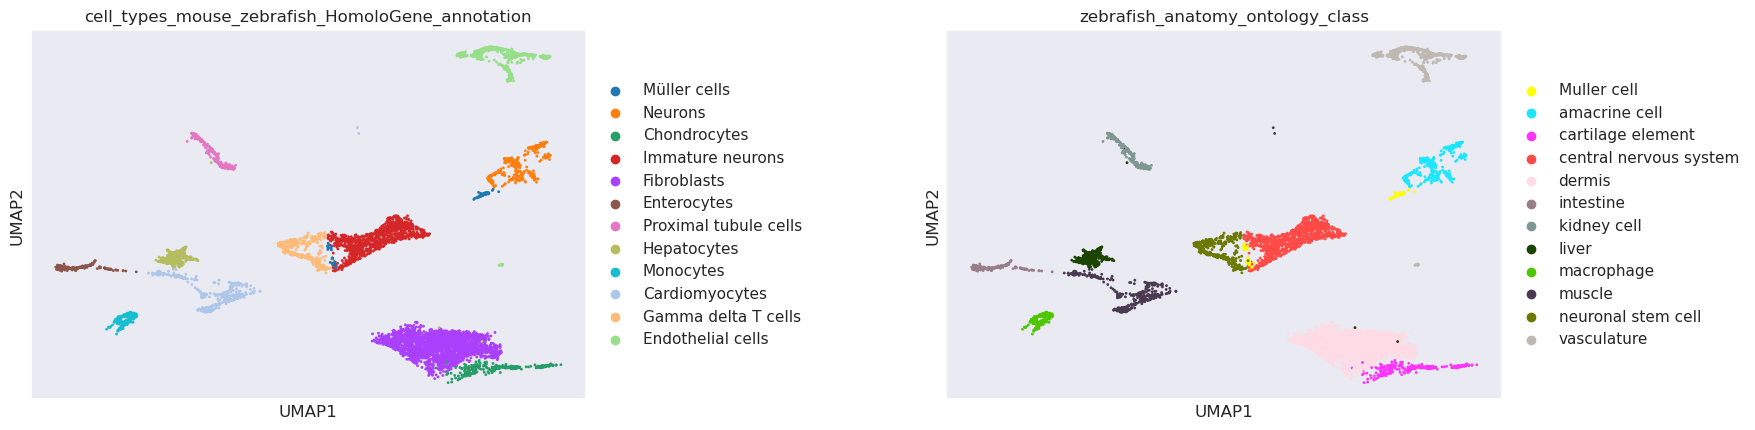

Tables of cell type annotation with clustering zebrafish_anatomy_ontology_class


,Cluster vasculature,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Endothelial cells,1539,57,94,16,0.724496,100
1,Endothelial cells (aorta),424,31,53,13,0.125000,17
2,Mesangial cells,371,19,41,16,0.056604,8
3,Platelets,350,29,68,13,0.108571,15
4,Müller cells,312,6,32,17,0.041667,6


,Cluster central nervous system,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Immature neurons,403,15,27,16,0.059553,9
1,Neural stem/precursor cells,379,21,37,12,0.102902,15
2,Neuroendocrine cells,340,7,19,19,0.008824,1
3,Germ cells,337,27,54,25,0.014837,2
4,Interneurons,332,59,150,15,0.111446,17


,Cluster intestine,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Enterocytes,759,44,78,12,0.693017,100
1,Transient cells,233,5,16,26,0.270386,39
2,Hepatocytes,170,24,79,16,0.058824,8
3,Proximal tubule cells,160,21,52,15,0.250000,36
4,Erythroid-like and erythroid precursor cells,120,9,37,25,0.033333,5


,Cluster neuronal stem cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Gamma delta T cells,1157,10,14,29,0.643907,100
1,Pluripotent stem cells,412,7,13,24,0.274272,43
2,Epithelial cells,299,17,54,18,0.100334,16
3,Neural stem/precursor cells,269,14,37,15,0.245353,38
4,Erythroid-like and erythroid precursor cells,203,13,37,23,0.088670,14


...

,Cluster kidney cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Proximal tubule cells,1031,30,52,20,0.445199,71
1,Hepatocytes,572,22,79,17,0.305944,49
2,Enterocytes,397,30,78,11,0.100756,16
3,Transient cells,357,7,16,28,0.280112,45
4,Oligodendrocytes,257,15,60,18,0.124514,20


,Cluster cartilage element,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Chondrocytes,178,15,28,14,0.337079,67
1,Endothelial cells (aorta),118,19,53,15,0.033898,7
2,Cajal-Retzius cells,114,14,64,17,0.017544,4
3,Pulmonary alveolar type I cells,112,8,17,13,0.017857,4
4,Proximal tubule cells,110,7,52,19,0.036364,7


,Cluster Muller cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Müller cells,217,14,32,15,0.281106,84
1,Neuroendocrine cells,156,7,19,15,0.025641,8
2,Transient cells,152,7,16,24,0.013158,4
3,Olfactory epithelial cells,150,28,88,25,0.180000,54
4,Endothelial cells,123,25,94,13,0.016260,5


Output folder: ./annotation/human_zebrafish_HomoloGene_annotation/ranked/output/zebrafish_anatomy_ontology_class/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/examples/transferred_markers/human_zebrafish_HomoloGene_annotation 
Cluster folder: ./annotation/human_zebrafish_HomoloGene_annotation/ranked/clusters/zebrafish_anatomy_ontology_class/ 
Tissue: all
Created folder: ./annotation/human_zebrafish_HomoloGene_annotation/ranked/output/zebrafish_anatomy_ontology_class
Writing ranked cluster file sample.cluster_vasculature (1/12)
Writing ranked cluster file sample.cluster_central nervous system (2/12)
Writing ranked cluster file sample.cluster_intestine (3/12)
Writing ranked cluster file sample.cluster_neuronal stem cell (4/12)
Writing ranked cluster file sample.cluster_amacrine cell (5/12)
Writing ranked cluster file sample.cluster_dermis (6/12)
Writing ranked cluster file sample.cluster_macrophage (7/12)
Writing ranked cluster file sample.cluster_l

/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


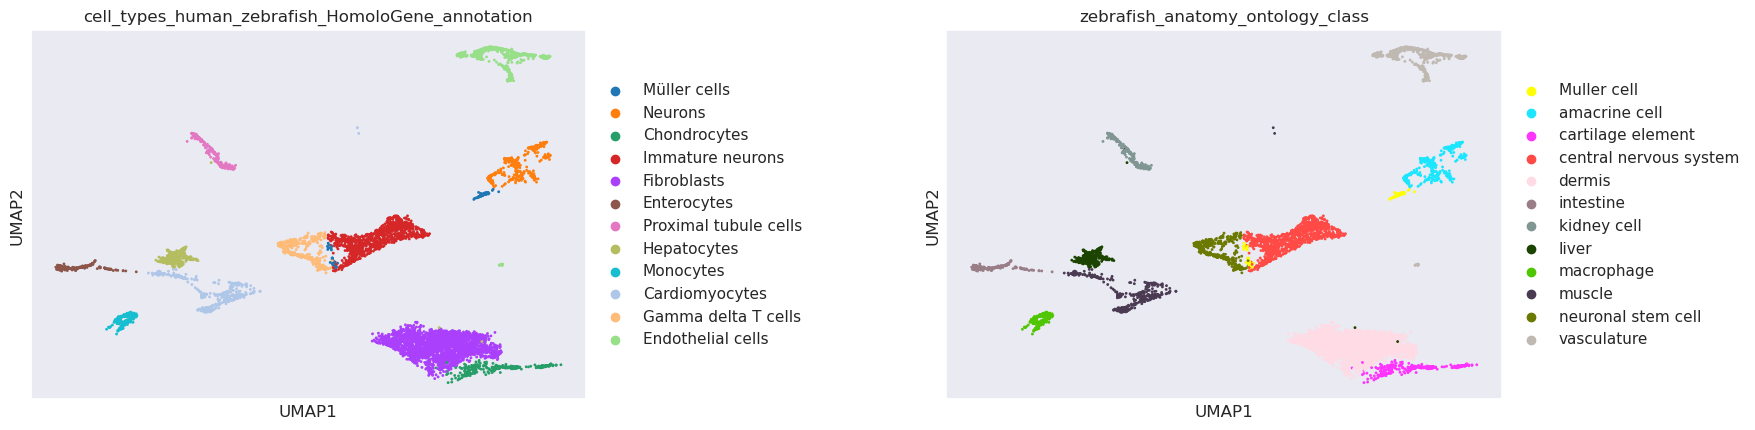

Tables of cell type annotation with clustering zebrafish_anatomy_ontology_class


,Cluster vasculature,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Endothelial cells,1482,56,95,16,0.711201,100
1,Endothelial cells (aorta),428,30,52,13,0.133178,19
2,Mesangial cells,371,19,41,16,0.056604,8
3,Platelets,350,29,68,13,0.082857,12
4,Peritubular myoid cells,321,9,18,15,0.024922,4


,Cluster central nervous system,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Immature neurons,403,15,27,16,0.064516,26
1,Neural stem/precursor cells,377,20,37,13,0.095491,38
2,Germ cells,341,27,53,24,0.002933,1
3,Neuroendocrine cells,340,7,19,19,0.026471,11
4,Interneurons,331,58,148,15,0.063444,25


,Cluster intestine,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Enterocytes,797,47,81,13,0.706399,100
1,Transient cells,234,6,16,22,0.106838,15
2,Epsilon cells,209,6,26,22,0.157895,22
3,Hepatocytes,176,25,84,17,0.107955,15
4,Proximal tubule cells,157,20,51,16,0.235669,33


,Cluster neuronal stem cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Gamma delta T cells,1186,11,15,29,0.652614,100
1,Pluripotent stem cells,412,7,13,24,0.266990,41
2,Epithelial cells,302,17,53,18,0.109272,17
3,Neural stem/precursor cells,269,14,37,15,0.223048,34
4,Erythroid-like and erythroid precursor cells,209,14,37,23,0.081340,12


...

,Cluster kidney cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Proximal tubule cells,1031,29,51,21,0.439379,70
1,Hepatocytes,578,22,84,18,0.283737,45
2,Enterocytes,414,32,81,13,0.137681,22
3,Transient cells,357,7,16,28,0.274510,44
4,Oligodendrocytes,259,15,59,18,0.104247,17


,Cluster cartilage element,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Chondrocytes,175,15,29,14,0.325714,98
1,Endothelial cells (aorta),118,18,52,16,0.025424,8
2,Cajal-Retzius cells,115,14,63,17,0.000000,0
3,Pulmonary alveolar type I cells,115,8,16,13,0.034783,10
4,Proximal tubule cells,111,7,51,19,0.009009,3


,Cluster Muller cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Müller cells,157,14,32,13,0.006369,2
1,Neuroendocrine cells,156,7,19,15,0.025641,8
2,Transient cells,152,7,16,24,0.006579,2
3,Olfactory epithelial cells,151,28,87,25,0.185430,56
4,Endothelial cells,123,25,95,13,0.008130,2


Output folder: ./annotation/mouse_zebrafish_BioMart_annotation/ranked/output/zebrafish_anatomy_ontology_class/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/examples/transferred_markers/mouse_zebrafish_BioMart_annotation 
Cluster folder: ./annotation/mouse_zebrafish_BioMart_annotation/ranked/clusters/zebrafish_anatomy_ontology_class/ 
Tissue: all
Created folder: ./annotation/mouse_zebrafish_BioMart_annotation/ranked/output/zebrafish_anatomy_ontology_class
Writing ranked cluster file sample.cluster_vasculature (1/12)
Writing ranked cluster file sample.cluster_central nervous system (2/12)
Writing ranked cluster file sample.cluster_intestine (3/12)
Writing ranked cluster file sample.cluster_neuronal stem cell (4/12)
Writing ranked cluster file sample.cluster_amacrine cell (5/12)
Writing ranked cluster file sample.cluster_dermis (6/12)
Writing ranked cluster file sample.cluster_macrophage (7/12)
Writing ranked cluster file sample.cluster_liver (8/12)


/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


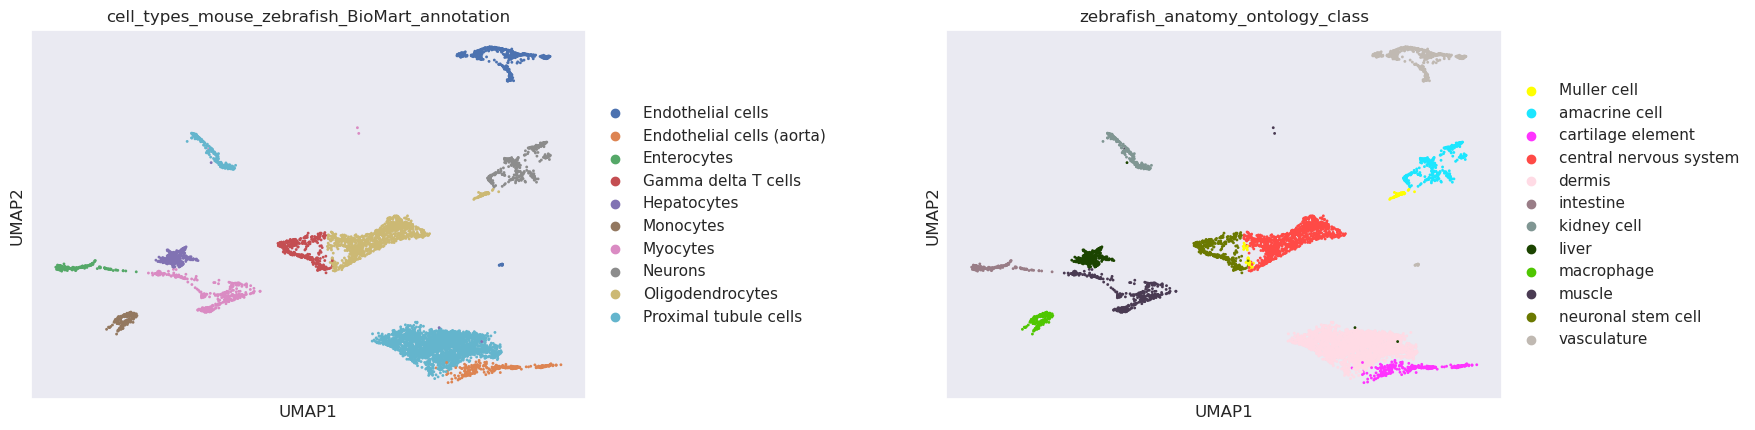

Tables of cell type annotation with clustering zebrafish_anatomy_ontology_class


,Cluster vasculature,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Endothelial cells,1631,65,92,17,0.683630,100
1,Endothelial cells (aorta),516,27,48,15,0.116279,17
2,Mesangial cells,456,21,35,18,0.326754,48
3,Platelets,307,24,59,13,0.068404,10
4,Podocytes,286,22,60,14,0.010490,2


,Cluster central nervous system,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Oligodendrocytes,426,27,49,20,0.049296,15
1,Germ cells,405,33,64,26,0.007407,2
2,Astrocytes,402,15,33,17,0.004975,1
3,Neural stem/precursor cells,400,17,32,15,0.030000,9
4,Neurons,388,53,115,18,0.046392,14


,Cluster intestine,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Enterocytes,801,46,80,15,0.594257,100
1,Adipocytes,325,17,62,15,0.230769,39
2,Proximal tubule cells,250,18,46,19,0.016000,3
3,Erythroid-like and erythroid precursor cells,246,12,45,27,0.113821,19
4,Hepatocytes,218,27,75,19,0.174312,29


,Cluster neuronal stem cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Gamma delta T cells,1255,12,17,30,0.658167,100
1,Pluripotent stem cells,429,8,13,25,0.095571,15
2,Epithelial cells,388,19,54,18,0.255155,39
3,Neural stem/precursor cells,289,13,32,17,0.141869,22
4,Erythroid-like and erythroid precursor cells,248,17,45,27,0.185484,28


...

,Cluster kidney cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Proximal tubule cells,1350,30,46,21,0.558519,100
1,Hepatocytes,596,23,75,19,0.031879,6
2,Enterocytes,577,34,80,16,0.285962,51
3,Adipocytes,412,19,62,14,0.128641,23
4,Erythroid-like and erythroid precursor cells,359,17,45,23,0.175487,31


,Cluster cartilage element,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Endothelial cells (aorta),147,23,48,16,0.047619,19
1,Microglia,140,12,32,17,0.057143,23
2,Proximal tubule cells,132,8,46,18,0.030303,12
3,Chondrocytes,128,11,23,13,0.039062,16
4,Podocytes,123,23,60,15,0.130081,52


,Cluster Muller cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Oligodendrocytes,202,19,49,19,0.168317,34
1,Olfactory epithelial cells,168,32,81,25,0.125000,25
2,Neurons,147,49,115,17,0.081633,16
3,Germ cells,135,25,64,26,0.022222,4
4,Enteric neurons,132,13,37,19,0.015152,3


Output folder: ./annotation/human_zebrafish_BioMart_annotation/ranked/output/zebrafish_anatomy_ontology_class/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/examples/transferred_markers/human_zebrafish_BioMart_annotation 
Cluster folder: ./annotation/human_zebrafish_BioMart_annotation/ranked/clusters/zebrafish_anatomy_ontology_class/ 
Tissue: all
Created folder: ./annotation/human_zebrafish_BioMart_annotation/ranked/output/zebrafish_anatomy_ontology_class
Writing ranked cluster file sample.cluster_vasculature (1/12)
Writing ranked cluster file sample.cluster_central nervous system (2/12)
Writing ranked cluster file sample.cluster_intestine (3/12)
Writing ranked cluster file sample.cluster_neuronal stem cell (4/12)
Writing ranked cluster file sample.cluster_amacrine cell (5/12)
Writing ranked cluster file sample.cluster_dermis (6/12)
Writing ranked cluster file sample.cluster_macrophage (7/12)
Writing ranked cluster file sample.cluster_liver (8/12)


/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


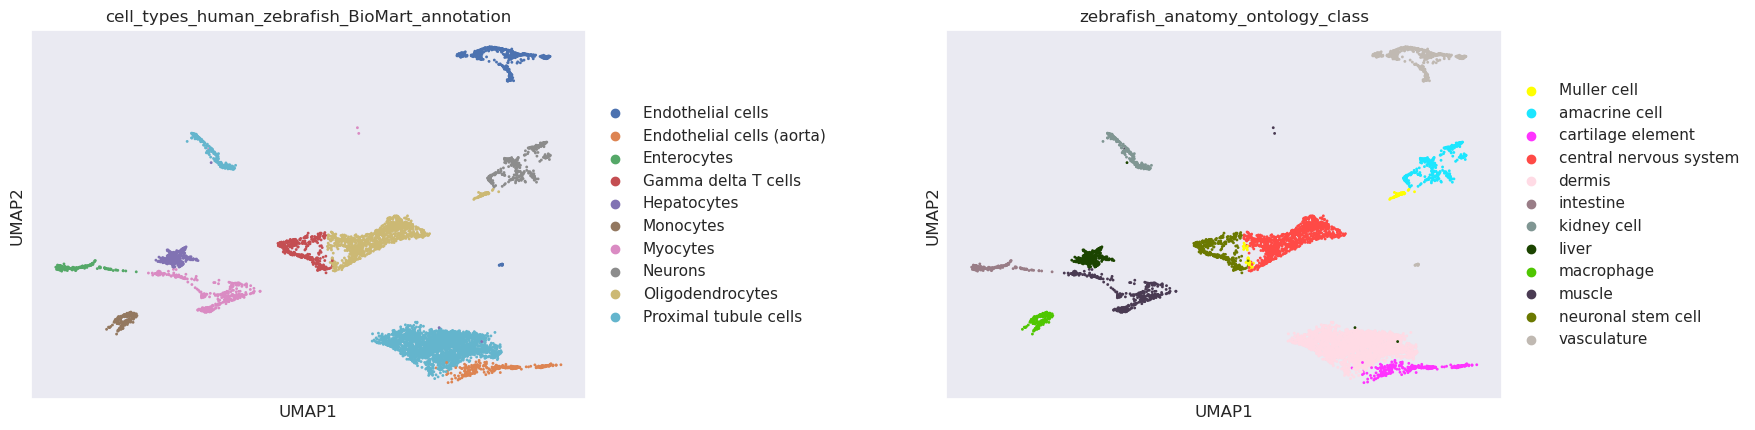

Tables of cell type annotation with clustering zebrafish_anatomy_ontology_class


,Cluster vasculature,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Endothelial cells,1585,66,93,17,0.671924,100
1,Endothelial cells (aorta),520,26,47,16,0.109615,16
2,Mesangial cells,463,21,34,18,0.323974,48
3,Monocytes,313,8,29,25,0.009585,1
4,Platelets,310,25,59,14,0.070968,11


,Cluster central nervous system,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Oligodendrocytes,421,27,50,20,0.035629,16
1,Neural stem/precursor cells,406,16,31,15,0.002463,1
2,Germ cells,405,33,64,27,0.022222,10
3,Astrocytes,396,15,34,17,0.005051,2
4,Neurons,394,53,112,18,0.060914,27


,Cluster intestine,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Enterocytes,758,47,83,15,0.573879,86
1,Adipocytes,323,18,63,14,0.040248,6
2,Epsilon cells,310,7,24,24,0.187097,28
3,Erythroid-like and erythroid precursor cells,252,12,43,27,0.134921,20
4,Proximal tubule cells,218,18,46,18,0.013761,2


,Cluster neuronal stem cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Gamma delta T cells,1281,13,18,30,0.668228,100
1,Pluripotent stem cells,425,9,14,26,0.096471,14
2,Epithelial cells,384,19,55,18,0.234375,35
3,Neural stem/precursor cells,294,13,31,17,0.139456,21
4,Erythroid-like and erythroid precursor cells,253,17,43,27,0.201581,30


...

,Cluster kidney cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Proximal tubule cells,1300,29,46,21,0.542308,100
1,Enterocytes,595,37,83,16,0.011765,2
2,Hepatocytes,588,24,77,19,0.278912,51
3,Adipocytes,424,20,63,13,0.134434,25
4,Erythroid-like and erythroid precursor cells,367,17,43,23,0.196185,36


,Cluster cartilage element,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Endothelial cells (aorta),148,22,47,16,0.054054,16
1,Microglia,140,12,32,17,0.057143,17
2,Proximal tubule cells,132,8,46,18,0.060606,18
3,Podocytes,124,23,59,15,0.112903,34
4,Pulmonary alveolar type I cells,110,8,18,13,0.045455,14


,Cluster Muller cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Oligodendrocytes,200,19,50,19,0.155000,26
1,Olfactory epithelial cells,169,32,80,25,0.118343,20
2,Neurons,149,49,112,17,0.093960,16
3,Germ cells,135,25,64,26,0.007407,1
4,Enteric neurons,134,14,37,18,0.044776,7


Output folder: ./annotation/zebrahub_no_homology_mouse/ranked/output/zebrafish_anatomy_ontology_class/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/examples/zebrahub_no_homology_mouse 
Cluster folder: ./annotation/zebrahub_no_homology_mouse/ranked/clusters/zebrafish_anatomy_ontology_class/ 
Tissue: all
Created folder: ./annotation/zebrahub_no_homology_mouse/ranked/output/zebrafish_anatomy_ontology_class
Writing ranked cluster file sample.cluster_vasculature (1/12)
Writing ranked cluster file sample.cluster_central nervous system (2/12)
Writing ranked cluster file sample.cluster_intestine (3/12)
Writing ranked cluster file sample.cluster_neuronal stem cell (4/12)
Writing ranked cluster file sample.cluster_amacrine cell (5/12)
Writing ranked cluster file sample.cluster_dermis (6/12)
Writing ranked cluster file sample.cluster_macrophage (7/12)
Writing ranked cluster file sample.cluster_liver (8/12)
Writing ranked cluster file sample.cluster_muscle (9

/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


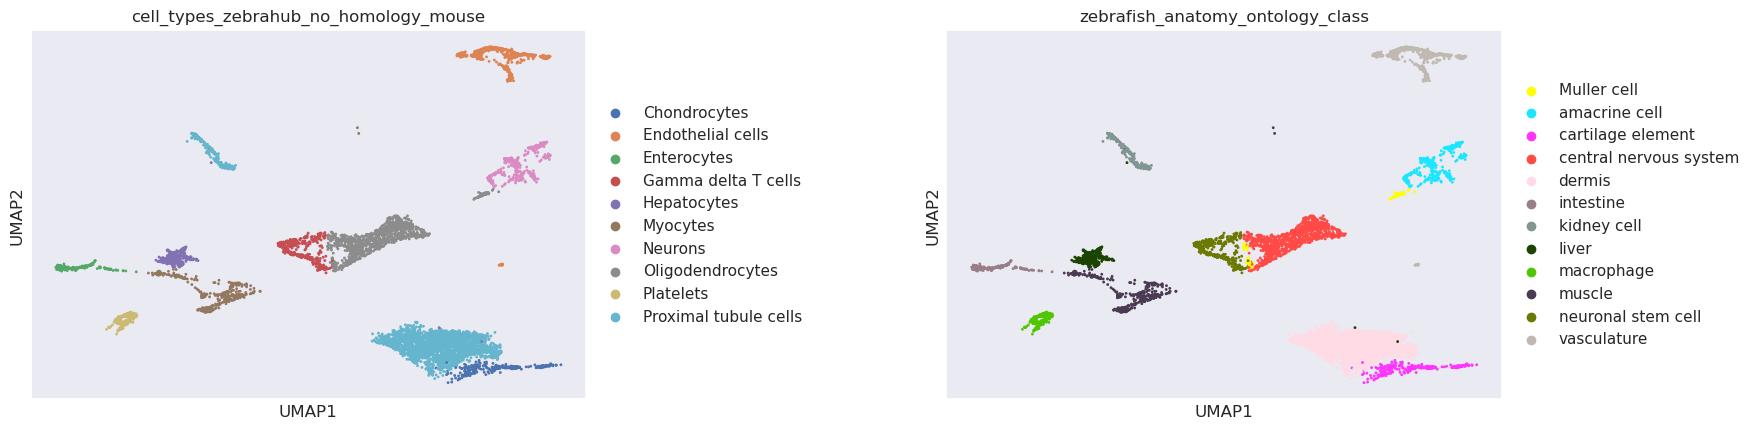

Tables of cell type annotation with clustering zebrafish_anatomy_ontology_class


,Cluster vasculature,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Endothelial cells,1506,68,194,18,0.775564,100
1,Endothelial cells (aorta),338,30,93,15,0.295858,38
2,Platelets,238,29,122,13,0.113445,15
3,Podocytes,211,21,99,16,0.033175,4
4,Hepatocytes,204,16,140,25,0.156863,20


,Cluster central nervous system,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Oligodendrocytes,291,29,92,20,0.037801,9
1,Immature neurons,280,9,38,19,0.007143,2
2,Crypt cells,278,7,18,11,0.028777,7
3,Neural stem/precursor cells,270,16,59,14,0.011111,3
4,Interneurons,267,56,227,15,0.052434,13


,Cluster intestine,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Enterocytes,569,44,154,14,0.557118,100
1,Adipocytes,252,19,118,17,0.158730,28
2,Hepatocytes,212,32,140,21,0.094340,17
3,Erythroid-like and erythroid precursor cells,192,11,74,26,0.036458,7
4,Mast cells,185,22,159,17,0.308108,55


,Cluster neuronal stem cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Gamma delta T cells,805,12,44,30,0.559006,100
1,Pluripotent stem cells,355,8,19,25,0.416901,75
2,Ciliated cells,207,7,18,16,0.135266,24
3,Epithelial cells,179,15,131,17,0.083799,15
4,Pancreatic progenitor cells,164,4,17,10,0.042683,8


...

,Cluster kidney cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Proximal tubule cells,764,27,86,20,0.388743,65
1,Hepatocytes,467,27,140,20,0.179872,30
2,Enterocytes,383,34,154,14,0.104439,17
3,Adipocytes,343,22,118,15,0.227405,38
4,Erythroid-like and erythroid precursor cells,265,17,74,22,0.264151,44


,Cluster cartilage element,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Chondrocytes,128,12,51,18,0.304688,91
1,Proximal tubule cells,89,8,86,21,0.101124,30
2,Myoepithelial cells,80,4,24,17,0.037500,11
3,Fibroblasts,77,40,181,9,0.025974,8
4,Pulmonary alveolar type I cells,75,7,37,15,0.013333,4


,Cluster Muller cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Oligodendrocytes,156,21,92,17,0.198718,40
1,Olfactory epithelial cells,125,34,136,24,0.056000,11
2,Podocytes,118,24,99,20,0.127119,25
3,Mast cells,103,28,159,21,0.048544,10
4,Neurons,98,42,214,17,0.183673,37


Output folder: ./annotation/zebrahub_no_homology_human/ranked/output/zebrafish_anatomy_ontology_class/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/examples/zebrahub_no_homology_human 
Cluster folder: ./annotation/zebrahub_no_homology_human/ranked/clusters/zebrafish_anatomy_ontology_class/ 
Tissue: all
Created folder: ./annotation/zebrahub_no_homology_human/ranked/output/zebrafish_anatomy_ontology_class
Writing ranked cluster file sample.cluster_vasculature (1/12)
Writing ranked cluster file sample.cluster_central nervous system (2/12)
Writing ranked cluster file sample.cluster_intestine (3/12)
Writing ranked cluster file sample.cluster_neuronal stem cell (4/12)
Writing ranked cluster file sample.cluster_amacrine cell (5/12)
Writing ranked cluster file sample.cluster_dermis (6/12)
Writing ranked cluster file sample.cluster_macrophage (7/12)
Writing ranked cluster file sample.cluster_liver (8/12)
Writing ranked cluster file sample.cluster_muscle (9

/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


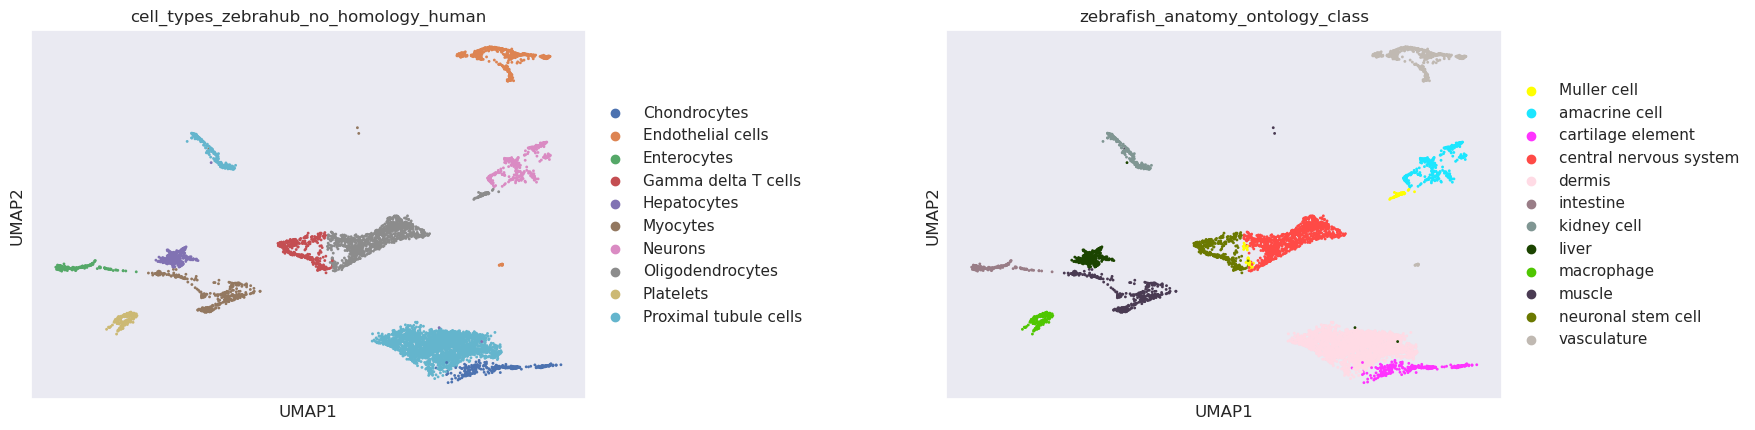

Tables of cell type annotation with clustering zebrafish_anatomy_ontology_class


,Cluster vasculature,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Endothelial cells,1514,69,194,18,0.772127,100
1,Endothelial cells (aorta),345,30,89,15,0.327536,42
2,Platelets,232,31,131,13,0.081897,11
3,Podocytes,213,21,98,16,0.079812,10
4,Hepatocytes,196,16,151,25,0.107143,14


,Cluster central nervous system,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Oligodendrocytes,291,29,92,20,0.037801,9
1,Immature neurons,280,9,38,19,0.007143,2
2,Crypt cells,278,7,18,11,0.021583,5
3,Neural stem/precursor cells,272,16,58,14,0.011029,3
4,Interneurons,269,56,224,15,0.037175,9


,Cluster intestine,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Enterocytes,581,45,151,14,0.571429,100
1,Adipocytes,249,19,121,17,0.176707,31
2,Hepatocytes,205,32,151,21,0.029268,5
3,Epsilon cells,199,7,45,24,0.020101,4
4,Mast cells,195,21,141,17,0.000000,0


,Cluster neuronal stem cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Gamma delta T cells,662,12,65,30,0.463746,93
1,Pluripotent stem cells,355,9,20,26,0.360563,72
2,Ciliated cells,227,7,15,16,0.211454,42
3,Epithelial cells,179,15,131,17,0.083799,17
4,Pancreatic progenitor cells,164,4,17,10,0.030488,6


...

,Cluster liver,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Hepatocytes,929,42,151,17,0.471475,71
1,Adipocytes,491,20,121,14,0.232179,35
2,Proximal tubule cells,377,19,79,18,0.442971,66
3,Olfactory epithelial cells,210,16,131,20,0.071429,11
4,Luteal cells,195,7,29,12,0.097436,15


,Cluster muscle,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Myocytes,342,26,89,12,0.347953,100
1,Cardiomyocytes,223,32,107,14,0.286996,82
2,Olfactory epithelial cells,159,19,131,20,0.138365,40
3,Hepatocytes,137,38,151,18,0.262774,76
4,Basal cells,101,9,56,13,0.039604,11


,Cluster kidney cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Proximal tubule cells,797,27,79,20,0.436637,73
1,Hepatocytes,449,27,151,20,0.102450,17
2,Enterocytes,403,35,151,15,0.158809,26
3,Adipocytes,339,22,121,15,0.206490,34
4,Erythroid-like and erythroid precursor cells,269,17,72,22,0.256506,43


,Cluster cartilage element,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Chondrocytes,126,12,52,18,0.261905,100
1,Proximal tubule cells,93,8,79,21,0.161290,62
2,Fibroblasts,78,40,176,9,0.000000,0
3,Pulmonary alveolar type I cells,78,7,35,15,0.012821,5
4,Myoepithelial cells,77,4,26,17,0.025974,10


,Cluster Muller cell,Score,Hits,Number of marker genes,Mean of UI,Normalized Diff,Scaled Diff
0,Oligodendrocytes,156,21,92,17,0.185897,37
1,Olfactory epithelial cells,127,34,131,24,0.062992,13
2,Podocytes,119,24,98,20,0.159664,32
3,Neurons,100,42,205,17,0.180000,36
4,Neuroendocrine cells,82,7,26,11,0.024390,5


In [12]:
for marker_list in marker_lists:
    name = marker_list.split("/")[-1]
    annotation_dir = f"./annotation/{name}"
    
    # Annotate
    annot.annot_ct(adata_filtered, output_path=annotation_dir, db_path=marker_list,
                   cluster_column=f"{column}", rank_genes_column=rank_genes_column, 
                   ct_column=f"cell_types_{name}")
    
    # Plot annotation
    sc.pl.umap(adata_filtered, color=[f'cell_types_{name}', f'{column}'], wspace=0.5)

    # Show scores and alternate cell types of eacht cluster
    print(f"Tables of cell type annotation with clustering {column}")
    annot.show_tables(annotation_dir=annotation_dir, n=5, clustering_column=column, show_diff=True)

### Compare cell type annotations from Zebrahub and MarkerRepo

In [13]:
compare_df = annot.compare_cell_types(adata_filtered, column, marker_lists)

In [14]:
unique_counts = compare_df.nunique()
display(unique_counts)

cell_types_mouse_zebrafish_HomoloGene_annotation    12
cell_types_human_zebrafish_HomoloGene_annotation    12
cell_types_mouse_zebrafish_BioMart_annotation       10
cell_types_human_zebrafish_BioMart_annotation       10
cell_types_zebrahub_no_homology_mouse               10
cell_types_zebrahub_no_homology_human               10
dtype: int64

In [15]:
compare_df.rename(columns={compare_df.columns[0]: "HG mouse",
                           compare_df.columns[1]: "HG human",
                           compare_df.columns[2]: "BM mouse",
                           compare_df.columns[3]: "BM human",
                           compare_df.columns[4]: "NT mouse",
                           compare_df.columns[5]: "NT human"}, inplace=True)
compare_df.index.name = "Zebrahub"
unique_counts = compare_df.nunique()
display(unique_counts)
display(compare_df)

HG mouse    12
HG human    12
BM mouse    10
BM human    10
NT mouse    10
NT human    10
dtype: int64

,HG mouse,HG human,BM mouse,BM human,NT mouse,NT human
Zebrahub,,,,,,
Muller cell,Müller cells,Müller cells,Oligodendrocytes,Oligodendrocytes,Oligodendrocytes,Oligodendrocytes
amacrine cell,Neurons,Neurons,Neurons,Neurons,Neurons,Neurons
cartilage element,Chondrocytes,Chondrocytes,Endothelial cells (aorta),Endothelial cells (aorta),Chondrocytes,Chondrocytes
central nervous system,Immature neurons,Immature neurons,Oligodendrocytes,Oligodendrocytes,Oligodendrocytes,Oligodendrocytes
dermis,Fibroblasts,Fibroblasts,Proximal tubule cells,Proximal tubule cells,Proximal tubule cells,Proximal tubule cells
intestine,Enterocytes,Enterocytes,Enterocytes,Enterocytes,Enterocytes,Enterocytes
kidney cell,Proximal tubule cells,Proximal tubule cells,Proximal tubule cells,Proximal tubule cells,Proximal tubule cells,Proximal tubule cells
liver,Hepatocytes,Hepatocytes,Hepatocytes,Hepatocytes,Hepatocytes,Hepatocytes
macrophage,Monocytes,Monocytes,Monocytes,Monocytes,Platelets,Platelets


### Save UMAP plot from Zebrahub with the analysed cell type clusters only

/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


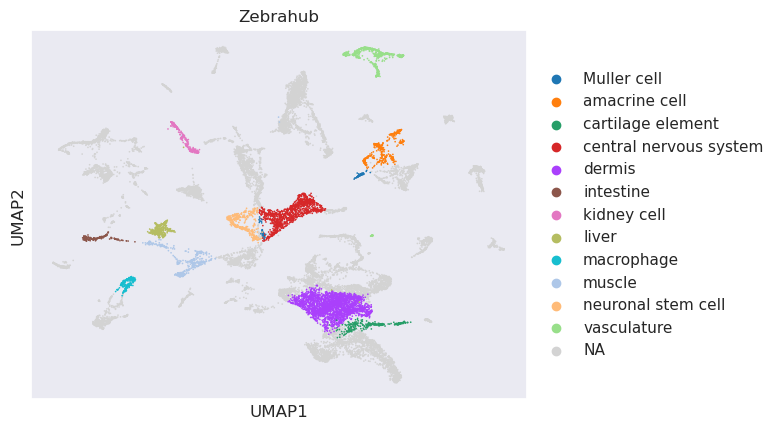

In [16]:
adata.obs['filtered_cell_types'] = [cell_type if cell_type in wanted_cell_types else None for cell_type in adata.obs['zebrafish_anatomy_ontology_class']]
sc.pl.umap(adata, color=['filtered_cell_types'], title='Zebrahub', save="zebrafish_filtered.png")